In [231]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [232]:

from matplotlib.lines import Line2D
from matplotlib.legend import Legend

Line2D._us_dashSeq = property(lambda self: self._dash_pattern[1])
Line2D._us_dashOffset = property(lambda self: self._dash_pattern[0])
Legend._ncol = property(lambda self: self._ncols)

In [233]:
from utils.datasets.base_dataset import QUERY_TYPE
from pathlib import Path
import pandas as pd
from utils.helpers import to_pow_10
from utils.helpers import pretty_print_counts



In [234]:
results_dir = Path("scratch") / "results"
figures_dir = Path("scratch") / "figures"
figures_dir.mkdir(exist_ok=True, parents=True)


def combine_dfs(pattern: str, base_dir: Path) -> pd.DataFrame:
    dfs = []
    for file in base_dir.glob(pattern):
        df = pd.read_csv(file)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


modes = {
    "bsbm": "BSBM-DVQ",
    "dbpedia": "DBpedia-MS",
}
mode = "bsbm"
# stats_df = combine_dfs(f"{mode}_stats*.csv", results_dir)
# timings_df = combine_dfs(f"{mode}_timings*.csv", results_dir)
timings_df = pd.read_csv(results_dir / mode / f"{mode}_timings_all.csv")
stats_df = pd.read_csv(results_dir / mode / f"{mode}_stats_all.csv")
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-05-12 21:19:24.648975,0.0,72261632,-1,-1,1,2418,3,easy,embedded,1,QLever
1,2026-05-12 21:19:24.797419,33.7,79941632,-1,-1,1,2418,3,easy,embedded,1,QLever
2,2026-05-12 21:19:24.948502,33.1,79937536,-1,-1,1,2418,3,easy,embedded,1,QLever
3,2026-05-12 21:19:25.098408,33.3,79958016,-1,-1,1,2418,3,easy,embedded,1,QLever
4,2026-05-12 21:19:25.246388,33.8,79958016,-1,-1,1,2418,3,easy,embedded,1,QLever
...,...,...,...,...,...,...,...,...,...,...,...,...
112466,2026-05-13 02:04:09.921108,0.0,726343680,-1,-1,1,35177974,7,hard,two_stage,100000,Fuseki + RDFTensor
112467,2026-05-13 02:04:17.525394,0.3,726343680,-1,-1,1,35177974,7,hard,two_stage,100000,Fuseki + RDFTensor
112468,2026-05-13 02:04:25.785013,0.0,726343680,-1,-1,1,35177974,7,hard,two_stage,100000,Fuseki + RDFTensor
112469,2026-05-13 02:04:36.093810,0.2,726343680,-1,-1,1,35177974,7,hard,two_stage,100000,Fuseki + RDFTensor


In [235]:
engine_mapping = {
    "Fuseki + RDFTensor": "RDFTensor",
    "Fuseki": "RDFTensor",
    "Qlever": "\\systemname-TV",
    "Qlever (no Tensor Vocabulary)": "\\systemname-Base",
    "QLever": "\\systemname-TV",
    "QLever (no Tensor Vocabulary)": "\\systemname-Base",
    "Neo4j": "Neo4j",
}
query_type_mapping = {
    "cypher_embedded": "embedded",
    "cypher_index": "index",
}
timings_df["engine"] = timings_df["engine"].map(engine_mapping)
timings_df["query_type"] = timings_df["query_type"].map(lambda x: query_type_mapping.get(x, x))
stats_df["engine"] = stats_df["engine"].map(engine_mapping)
stats_df["query_type"] = stats_df["query_type"].map(lambda x: query_type_mapping.get(x, x))
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-05-12 21:19:24.648975,0.0,72261632,-1,-1,1,2418,3,easy,embedded,1,\systemname-TV
1,2026-05-12 21:19:24.797419,33.7,79941632,-1,-1,1,2418,3,easy,embedded,1,\systemname-TV
2,2026-05-12 21:19:24.948502,33.1,79937536,-1,-1,1,2418,3,easy,embedded,1,\systemname-TV
3,2026-05-12 21:19:25.098408,33.3,79958016,-1,-1,1,2418,3,easy,embedded,1,\systemname-TV
4,2026-05-12 21:19:25.246388,33.8,79958016,-1,-1,1,2418,3,easy,embedded,1,\systemname-TV
...,...,...,...,...,...,...,...,...,...,...,...,...
112466,2026-05-13 02:04:09.921108,0.0,726343680,-1,-1,1,35177974,7,hard,two_stage,100000,RDFTensor
112467,2026-05-13 02:04:17.525394,0.3,726343680,-1,-1,1,35177974,7,hard,two_stage,100000,RDFTensor
112468,2026-05-13 02:04:25.785013,0.0,726343680,-1,-1,1,35177974,7,hard,two_stage,100000,RDFTensor
112469,2026-05-13 02:04:36.093810,0.2,726343680,-1,-1,1,35177974,7,hard,two_stage,100000,RDFTensor


In [236]:
timings_df[(timings_df["query_type"] == "index") & (timings_df["engine"] == "QLever (TV)") & (timings_df["difficulty"] == "hard")].sort_values("size")

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time


In [237]:
import numpy as np
timings_df = timings_df[timings_df["elapsed_time"].replace([np.inf, -np.inf], np.nan).notna()]

In [238]:
hard_timings = timings_df[timings_df["difficulty"] == "hard"]
hard_timings

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time
384,2418,3,1,0,\systemname-TV,hard,embedded,0.010601,-1.0,-1.0,0.01
385,2418,3,1,1,\systemname-TV,hard,embedded,0.006430,-1.0,-1.0,0.00
386,2418,3,1,2,\systemname-TV,hard,embedded,0.006508,-1.0,-1.0,0.01
387,2418,3,1,3,\systemname-TV,hard,embedded,0.006042,-1.0,-1.0,0.00
388,2418,3,1,4,\systemname-TV,hard,embedded,0.005937,-1.0,-1.0,0.01
...,...,...,...,...,...,...,...,...,...,...,...
7220,3577077,6,10000,123,\systemname-Base,hard,index,8.181027,-1.0,-1.0,8.34
7221,3577077,6,10000,124,\systemname-Base,hard,index,8.031011,-1.0,-1.0,8.21
7222,3577077,6,10000,125,\systemname-Base,hard,index,8.252609,-1.0,-1.0,8.41
7223,3577077,6,10000,126,\systemname-Base,hard,index,7.984693,-1.0,-1.0,8.15


In [239]:
# timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['\systemname-TV', '\systemname-Base', 'Neo4j', 'RDFTensor']
Length: 4, dtype: str

In [240]:
engines = timings_df["engine"].sort_values().unique()
difficulties = timings_df["difficulty"].unique()
query_types = timings_df["query_type"].unique()
engines, difficulties, query_types

(<ArrowStringArray>
 ['Neo4j', 'RDFTensor', '\systemname-Base', '\systemname-TV']
 Length: 4, dtype: str,
 <ArrowStringArray>
 ['easy', 'hard']
 Length: 2, dtype: str,
 <ArrowStringArray>
 ['embedded', 'index', 'two_stage']
 Length: 3, dtype: str)

In [241]:
type_map = {
    "index": "Index",
    "embedded": "Embedded",
    "two_stage": "Two Stage",
}
timings_df["query_type"] = timings_df["query_type"].map(type_map, na_action="ignore")
stats_df["query_type"] = stats_df["query_type"].map(type_map, na_action="ignore")

In [242]:
timings_df

,size,power,estimated_size,rep,engine,difficulty,query_type,elapsed_time,ndcg_score,recall_score,wall_time
0,2418,3,1,0,\systemname-TV,easy,Embedded,0.008924,0.000000,1.0,0.01
1,2418,3,1,1,\systemname-TV,easy,Embedded,0.004692,0.000000,1.0,0.00
2,2418,3,1,2,\systemname-TV,easy,Embedded,0.004596,0.000000,1.0,0.01
3,2418,3,1,3,\systemname-TV,easy,Embedded,0.005278,0.000000,1.0,0.00
4,2418,3,1,4,\systemname-TV,easy,Embedded,0.004193,0.000000,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
7870,35177974,7,100000,123,\systemname-Base,easy,Index,0.138471,0.696932,0.1,0.38
7871,35177974,7,100000,124,\systemname-Base,easy,Index,0.142302,0.696932,0.1,0.40
7872,35177974,7,100000,125,\systemname-Base,easy,Index,0.140623,0.696932,0.1,0.39
7873,35177974,7,100000,126,\systemname-Base,easy,Index,0.141726,0.696932,0.1,0.39


In [243]:
engines = list(timings_df["engine"].unique())
engines.sort()
baseline_engine = engines[0 if mode == "dbpedia" else 1]

from scipy.stats import ttest_ind, ttest_1samp, median_test, gmean


def siginificance_level(p_value: float) -> str:
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"



# calculate the mean speedup vs the baseline engine for each difficulty + query type + engine + size
# + whether the speedup is statistically significant (using a t-test)
# the baseline engine
def calculate_speedup(
    df: pd.DataFrame, baseline_engine: str, baseline_type: str, relevant_measure: str
) -> pd.DataFrame:
    results = []
    chunks = df.groupby(
        ["difficulty", "query_type", "engine", "estimated_size", "size"]
    )
    super_chunks = df.groupby(
        [
            "difficulty",
            "query_type",
            "engine",
        ]
    )
    for i, group in chunks:
        super_group = super_chunks.get_group(
            (
                group["difficulty"].iloc[0],
                group["query_type"].iloc[0],
                group["engine"].iloc[0],
            )
        )
        if group.empty:
            continue
        baseline_group = df[
            (df["difficulty"] == group["difficulty"].iloc[0])
            & (df["query_type"] == baseline_type)
            & (df["engine"] == baseline_engine)
            & (df["estimated_size"] == group["estimated_size"].iloc[0])
            & (df["size"] == group["size"].iloc[0])
        ]
        measure_group = group[relevant_measure]
        measure_baseline_group: pd.Series = baseline_group[relevant_measure]
        # vs baseline group using a t-test
        t_stat, p_value_baseline = ttest_ind(
            measure_group, measure_baseline_group, equal_var=False, alternative="less"
        )
        # vs first measure of the group (cold start) using a t-test
        cold_start_measure = measure_group.iloc[0]
        t_stat_cold, p_value_cold = ttest_1samp(
            measure_baseline_group, cold_start_measure, alternative="two-sided"
        )

        adjusted_alpha = 0.01 / len(chunks)  # Bonferroni correction
        speedup = measure_baseline_group.median() / measure_group.median()
        speedup_cold = measure_baseline_group.median() / cold_start_measure
        result = {
            "difficulty": group["difficulty"].iloc[0],
            "query_type": group["query_type"].iloc[0],
            "engine": group["engine"].iloc[0],
            "estimated_size": group["estimated_size"].iloc[0],
            "size": group["size"].iloc[0],
            "measure": gmean(measure_group),
            "speedup": speedup,
            "speedup_cold": speedup_cold,
            "p_value_baseline": p_value_baseline,
            "p_value_cold": p_value_cold,
            "significance_level": siginificance_level(p_value_baseline),
            "significant": p_value_baseline < adjusted_alpha,
            "siginificance_level_cold": siginificance_level(p_value_cold),
            "significant_cold": p_value_cold < adjusted_alpha,
        }
        if mode == "dbpedia":
            del result["estimated_size"]
        
        results.append(result)
    df = pd.DataFrame(results)
    # index by difficulty, query type, engine, size
    # df.set_index(["difficulty", "query_type", "engine", "size"], inplace=True)
    return df


speedup = calculate_speedup(timings_df, baseline_engine, "Embedded", "elapsed_time")
speedup

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_52754/2766978918.py:57: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value_baseline = ttest_ind(
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_52754/2766978918.py:62: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat_cold, p_value_cold = ttest_1samp(
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_52754/2766978918.py:57: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_value_baseline = ttest_ind(
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_52754/2766978918.py:62: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation

,difficulty,query_type,engine,estimated_size,size,measure,speedup,speedup_cold,p_value_baseline,p_value_cold,significance_level,significant,siginificance_level_cold,significant_cold
0,easy,Embedded,Neo4j,1,2418,0.039376,0.374316,0.027948,9.999945e-01,2.230974e-132,ns,False,***,True
1,easy,Embedded,Neo4j,10,5595,0.043705,0.638684,0.052257,9.713203e-01,4.254435e-118,ns,False,***,True
2,easy,Embedded,Neo4j,100,42417,0.080831,1.768554,0.234938,7.359939e-15,6.027527e-74,***,True,***,True
3,easy,Embedded,Neo4j,1000,383751,0.369812,4.095244,1.431741,2.053676e-85,3.071863e-39,***,True,***,True
4,easy,Embedded,Neo4j,10000,3577077,3.775083,4.251058,3.580889,1.420831e-107,1.672056e-103,***,True,***,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,hard,Index,\systemname-TV,1,2418,0.006396,4.220269,0.244936,1.187195e-07,6.977400e-26,***,True,***,True
59,hard,Index,\systemname-TV,10,5595,0.010183,262.957013,33.684387,2.873389e-129,1.850174e-127,***,True,***,True
60,hard,Index,\systemname-TV,100,42417,0.068066,NaN,NaN,NaN,NaN,ns,False,ns,False
61,hard,Index,\systemname-TV,1000,383751,1.105949,NaN,NaN,NaN,NaN,ns,False,ns,False


In [244]:

sizes = speedup["size"].unique()
estimate_size_mapping= {}
if mode == "bsbm":

    estimate_size_mapping = {
        size: speedup[speedup["size"] == size]["estimated_size"].iloc[0] for size in sizes
    }
    estimate_size_mapping


In [245]:
speedup_complete = speedup.copy()
for difficulty in speedup["difficulty"].unique():
    for query_type in speedup["query_type"].unique():
        for engine in engines:
            for size in sizes:
                df = speedup[
                    (speedup["difficulty"] == difficulty)
                    & (speedup["query_type"] == query_type)
                    & (speedup["engine"] == engine)
                    & (speedup["size"] == size)
                ]
                if df.empty:
                    empty_measure = {
                        "difficulty": difficulty,
                        "query_type": query_type,
                        "engine": engine,
                        "size": size,
                        "measure": np.nan,
                        "speedup": np.nan,
                        "speedup_cold": np.nan,
                        "p_value_baseline": np.nan,
                        "p_value_cold": np.nan,
                        "significance_level": "ns",
                        "significant": False,
                        "siginificance_level_cold": "ns",
                        "significant_cold": False,
                    }
                    if size in estimate_size_mapping:
                        empty_measure["estimated_size"] = estimate_size_mapping[size]
                    df = pd.DataFrame([empty_measure])
                    speedup_complete = pd.concat(
                        [speedup_complete, df], ignore_index=True
                    )
                    print("Added empty measure for", difficulty, query_type, engine)
speedup_complete.sort_values(
    ["difficulty", "query_type", "engine", "size"], inplace=True
)
speedup_complete

Added empty measure for easy Embedded Neo4j
Added empty measure for easy Embedded RDFTensor
Added empty measure for easy Embedded \systemname-Base
Added empty measure for easy Index Neo4j
Added empty measure for easy Index Neo4j
Added empty measure for easy Index Neo4j
Added empty measure for easy Index Neo4j
Added empty measure for easy Index Neo4j
Added empty measure for easy Index Neo4j
Added empty measure for easy Index RDFTensor
Added empty measure for easy Index RDFTensor
Added empty measure for easy Index RDFTensor
Added empty measure for easy Index RDFTensor
Added empty measure for easy Index RDFTensor
Added empty measure for easy Index RDFTensor
Added empty measure for easy Two Stage Neo4j
Added empty measure for easy Two Stage Neo4j
Added empty measure for easy Two Stage Neo4j
Added empty measure for easy Two Stage Neo4j
Added empty measure for easy Two Stage Neo4j
Added empty measure for easy Two Stage Neo4j
Added empty measure for easy Two Stage RDFTensor
Added empty measur

,difficulty,query_type,engine,estimated_size,size,measure,speedup,speedup_cold,p_value_baseline,p_value_cold,significance_level,significant,siginificance_level_cold,significant_cold
0,easy,Embedded,Neo4j,1,2418,0.039376,0.374316,0.027948,9.999945e-01,2.230974e-132,ns,False,***,True
1,easy,Embedded,Neo4j,10,5595,0.043705,0.638684,0.052257,9.713203e-01,4.254435e-118,ns,False,***,True
2,easy,Embedded,Neo4j,100,42417,0.080831,1.768554,0.234938,7.359939e-15,6.027527e-74,***,True,***,True
3,easy,Embedded,Neo4j,1000,383751,0.369812,4.095244,1.431741,2.053676e-85,3.071863e-39,***,True,***,True
4,easy,Embedded,Neo4j,10000,3577077,3.775083,4.251058,3.580889,1.420831e-107,1.672056e-103,***,True,***,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,hard,Two Stage,\systemname-TV,10,5595,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False
140,hard,Two Stage,\systemname-TV,100,42417,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False
141,hard,Two Stage,\systemname-TV,1000,383751,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False
142,hard,Two Stage,\systemname-TV,10000,3577077,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False


In [246]:
speedup

,difficulty,query_type,engine,estimated_size,size,measure,speedup,speedup_cold,p_value_baseline,p_value_cold,significance_level,significant,siginificance_level_cold,significant_cold
0,easy,Embedded,Neo4j,1,2418,0.039376,0.374316,0.027948,9.999945e-01,2.230974e-132,ns,False,***,True
1,easy,Embedded,Neo4j,10,5595,0.043705,0.638684,0.052257,9.713203e-01,4.254435e-118,ns,False,***,True
2,easy,Embedded,Neo4j,100,42417,0.080831,1.768554,0.234938,7.359939e-15,6.027527e-74,***,True,***,True
3,easy,Embedded,Neo4j,1000,383751,0.369812,4.095244,1.431741,2.053676e-85,3.071863e-39,***,True,***,True
4,easy,Embedded,Neo4j,10000,3577077,3.775083,4.251058,3.580889,1.420831e-107,1.672056e-103,***,True,***,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,hard,Index,\systemname-TV,1,2418,0.006396,4.220269,0.244936,1.187195e-07,6.977400e-26,***,True,***,True
59,hard,Index,\systemname-TV,10,5595,0.010183,262.957013,33.684387,2.873389e-129,1.850174e-127,***,True,***,True
60,hard,Index,\systemname-TV,100,42417,0.068066,NaN,NaN,NaN,NaN,ns,False,ns,False
61,hard,Index,\systemname-TV,1000,383751,1.105949,NaN,NaN,NaN,NaN,ns,False,ns,False


In [247]:
for do_cold_start in [False, True]:
    for sp, f in zip(
        [speedup, speedup_complete],
        ["", "complete"],
    ):
        for twocol in [False, True]:
            print(
                f"Processing {mode} with cold start = {do_cold_start} and file suffix = {f}"
            )
            caption = f"Speedup of \\systemname compared to {baseline_engine} for our {modes[mode]}. The time is the median time over the group, significant speedups are indicated in \\textbf{{bold}}."
            if f != "complete":
                caption += " Query combinations that timed out are omitted."
            # filter out tw stage TV queries
            sp_ = sp[~((sp["query_type"] == "Two Stage") & (sp["engine"] == "\\systemname-TV"))]

            mapping = {
                "difficulty": "Difficulty",
                "query_type": "Query Type",
                "estimated_size": "$m$",
                "measure": "$t$ (s)",
                "engine": "Engine",
                "speedup": "Speedup",
                # "p_value_baseline": "$p$-value (Baseline)",
                # "speedup_cold": "Speedup (Cold Start)",
                # "p_value_cold": "$p$-value (Cold Start)",
                # "significance_level": "Significance",
                # "significant": "Significant",
            }
            fname = f"{mode}_speedup{f}.tex"
            if do_cold_start:
                caption += " The speedup significance for the cold is compared to the same warm timings."
                mapping["speedup"] = "Speedup (vs Baseline)"
                mapping["speedup_cold"] = "Speedup (vs Cold Start)"
                fname = f"{mode}_speedup_cold{f}.tex"
            if twocol:
                fname = fname.replace(".tex", "_twocol.tex")
            pretty_print_counts(
                sp_,
                figures_dir / fname,
                column_mapping=mapping,
                format_cols=["estimated_size", "measure", "speedup", "speedup_cold"]
                if do_cold_start
                else ["estimated_size", "measure", "speedup"],
                to_int_cols=["estimated_size"],
                index_cols=["difficulty", "query_type", "engine", "estimated_size"],
                label_xtra=f"{mode}_speedup{f}",
                caption=caption,
                significant_cols=["significant", "significant_cold"]
                if do_cold_start
                else ["significant"],
                significant_affected_cols=["speedup", "speedup_cold"]
                if do_cold_start
                else ["speedup"],
                twocol=twocol,
            )

Processing bsbm with cold start = False and file suffix = 
['estimated_size', 'measure', 'speedup'] ['difficulty', 'query_type', 'engine']
Indexing by ['Difficulty', 'Query Type', 'Engine', '$m$']
Col: col='speedup', Idx: idx_local=0 significant_col_vals[idx_local]=[False, False, True, True, True, False, False, False, False, False, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, False, True, True, True, True, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, True, False, True, True, False, False, False, True, True, False, False, False]
Value: 0.37431567149992423, Significant: False
Col: col='speedup', Idx: idx_local=0 significant_col_vals[idx_local]=[False, True, True, True, False, False, False, False, False, True, True, True, True, True, True, True, True, True, True, False, True, True, True, True, True, False, True, True, True, True, True, False, False, False, False, False, Fals

In [248]:
sp

,difficulty,query_type,engine,estimated_size,size,measure,speedup,speedup_cold,p_value_baseline,p_value_cold,significance_level,significant,siginificance_level_cold,significant_cold
0,easy,Embedded,Neo4j,1,2418,0.039376,0.374316,0.027948,9.999945e-01,2.230974e-132,ns,False,***,True
1,easy,Embedded,Neo4j,10,5595,0.043705,0.638684,0.052257,9.713203e-01,4.254435e-118,ns,False,***,True
2,easy,Embedded,Neo4j,100,42417,0.080831,1.768554,0.234938,7.359939e-15,6.027527e-74,***,True,***,True
3,easy,Embedded,Neo4j,1000,383751,0.369812,4.095244,1.431741,2.053676e-85,3.071863e-39,***,True,***,True
4,easy,Embedded,Neo4j,10000,3577077,3.775083,4.251058,3.580889,1.420831e-107,1.672056e-103,***,True,***,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,hard,Two Stage,\systemname-TV,10,5595,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False
140,hard,Two Stage,\systemname-TV,100,42417,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False
141,hard,Two Stage,\systemname-TV,1000,383751,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False
142,hard,Two Stage,\systemname-TV,10000,3577077,NaN,NaN,NaN,NaN,NaN,ns,False,ns,False


In [249]:
speedup

,difficulty,query_type,engine,estimated_size,size,measure,speedup,speedup_cold,p_value_baseline,p_value_cold,significance_level,significant,siginificance_level_cold,significant_cold
0,easy,Embedded,Neo4j,1,2418,0.039376,0.374316,0.027948,9.999945e-01,2.230974e-132,ns,False,***,True
1,easy,Embedded,Neo4j,10,5595,0.043705,0.638684,0.052257,9.713203e-01,4.254435e-118,ns,False,***,True
2,easy,Embedded,Neo4j,100,42417,0.080831,1.768554,0.234938,7.359939e-15,6.027527e-74,***,True,***,True
3,easy,Embedded,Neo4j,1000,383751,0.369812,4.095244,1.431741,2.053676e-85,3.071863e-39,***,True,***,True
4,easy,Embedded,Neo4j,10000,3577077,3.775083,4.251058,3.580889,1.420831e-107,1.672056e-103,***,True,***,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,hard,Index,\systemname-TV,1,2418,0.006396,4.220269,0.244936,1.187195e-07,6.977400e-26,***,True,***,True
59,hard,Index,\systemname-TV,10,5595,0.010183,262.957013,33.684387,2.873389e-129,1.850174e-127,***,True,***,True
60,hard,Index,\systemname-TV,100,42417,0.068066,NaN,NaN,NaN,NaN,ns,False,ns,False
61,hard,Index,\systemname-TV,1000,383751,1.105949,NaN,NaN,NaN,NaN,ns,False,ns,False


In [250]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
mean_timings = groupings.mean().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [251]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
symbols = {eng: symbol for eng, symbol in zip(engines, ["o", "s", "D", "^", "1"])}
colors, symbols

({'Neo4j': 'C0',
  'RDFTensor': 'C1',
  '\\systemname-Base': 'C2',
  '\\systemname-TV': 'C3'},
 {'Neo4j': 'o',
  'RDFTensor': 's',
  '\\systemname-Base': 'D',
  '\\systemname-TV': '^'})

In [252]:
mean_timings

,estimated_size,engine,difficulty,query_type,elapsed_time
0,1,Neo4j,easy,Embedded,0.043524
1,1,Neo4j,hard,Embedded,0.052812
2,1,RDFTensor,easy,Embedded,0.019786
3,1,RDFTensor,easy,Two Stage,0.132981
4,1,RDFTensor,hard,Embedded,0.036201
...,...,...,...,...,...
58,10000,\systemname-TV,easy,Index,0.030057
59,10000,\systemname-TV,hard,Index,7.227539
60,100000,\systemname-Base,easy,Index,0.177097
61,100000,\systemname-TV,easy,Embedded,3.067132


In [253]:
import matplotlib.pyplot as plt
import tikzplotlib
import seaborn as sns
import numpy as np

plt.rc("text", usetex=True)
plt.rc("text.latex", preamble="""\\usepackage{amsmath} \\newcommand{\\systemname}{\\textsc{QLever}}""")
plt.style.use("fivethirtyeight")
# set background color to white of the figure and axes
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

palette = sns.color_palette('colorblind').as_hex()
def adjust_lightness(color, amount=1.1):
    import matplotlib.colors as mc
    import colorsys

    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], np.maximum(0, np.minimum(1, amount * c[1])), c[2])

plt.rcParams.update({'errorbar.capsize': 2})

Quantiles [0.05, 0.5, 0.95]
Extrapolated sizes for \systemname-Base - embedded: [3577077, 35177974] [8.042517172987573, 217.95739291431815] existing points [2418, 5595, 42417, 383751, 3577077] [0.0046734489733353, 0.01308329252060495, 0.08494246995542196, 0.7124772621318698, 8.042517172987573]
Extrapolated sizes for RDFTensor - embedded: [3577077, 35177974] [15.95212312345393, 373.116285273232] existing points [2418, 5595, 42417, 383751, 3577077] [0.01341850787866855, 0.02622730890288945, 0.1366827335441485, 1.4717011864995584, 15.95212312345393]
Extrapolated sizes for Neo4j - embedded: [3577077, 35177974] [3.7525069264229387, 105.55625948318374] existing points [2418, 5595, 42417, 383751, 3577077] [0.0358481060247868, 0.04106457799207415, 0.07728501304518426, 0.35936833755113184, 3.7525069264229387]
Quantiles [0.05, 0.5, 0.95]
Extrapolated sizes for \systemname-TV - embedded: [42417, 383751, 3577077, 35177974] [17.835645704064518, 1598.4072663019185, 140254.45859160117, 13578811.50511

/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0]
Extrapolated sizes for \systemname-Base - embedded: [3577077, 35177974] [8.042517172987573, 217.95739291431815] existing points [2418, 5595, 42417, 383751, 3577077] [0.0046734489733353, 0.01308329252060495, 0.08494246995542196, 0.7124772621318698, 8.042517172987573]
Extrapolated sizes for RDFTensor - embedded: [3577077, 35177974] [15.95212312345393, 373.116285273232] existing points [2418, 5595, 42417, 383751, 3577077] [0.01341850787866855, 0.02622730890288945, 0.1366827335441485, 1.4717011864995584, 15.95212312345393]
Extrapolated sizes for Neo4j - embedded: [3577077, 35177974] [3.7525069264229387, 105.55625948318374] existing points [2418, 5595, 42417, 383751, 3577077] [0.0358481060247868, 0.04106457799207415, 0.07728501304518426, 0.35936833755113184, 3.7525069264229387]
Quantiles [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.

/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/numpy/polynomial/polynomial.py:1436: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


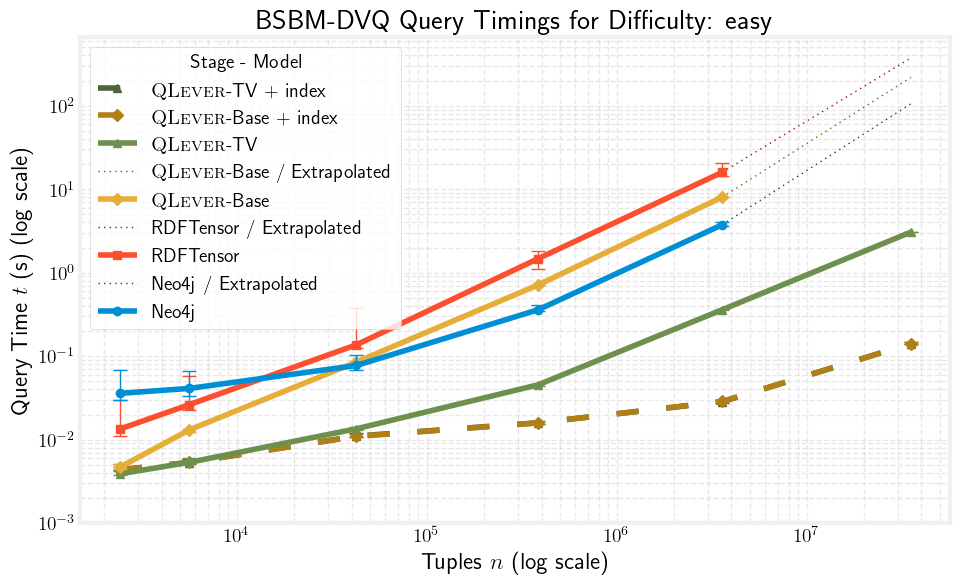

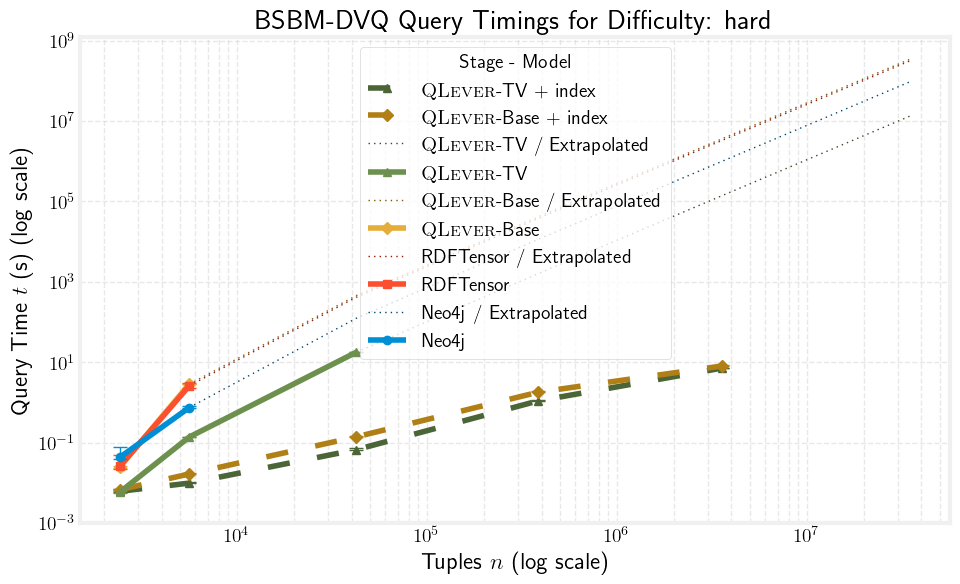

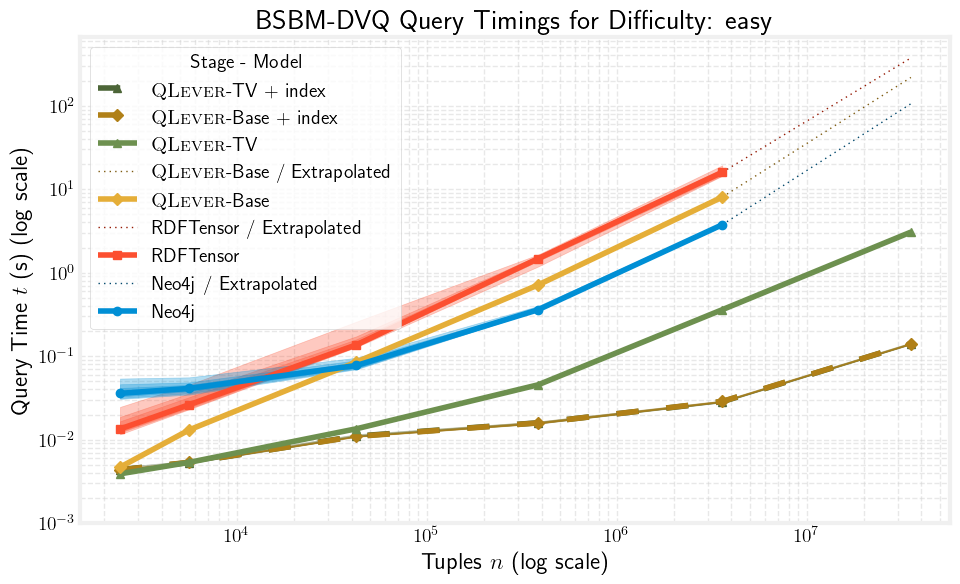

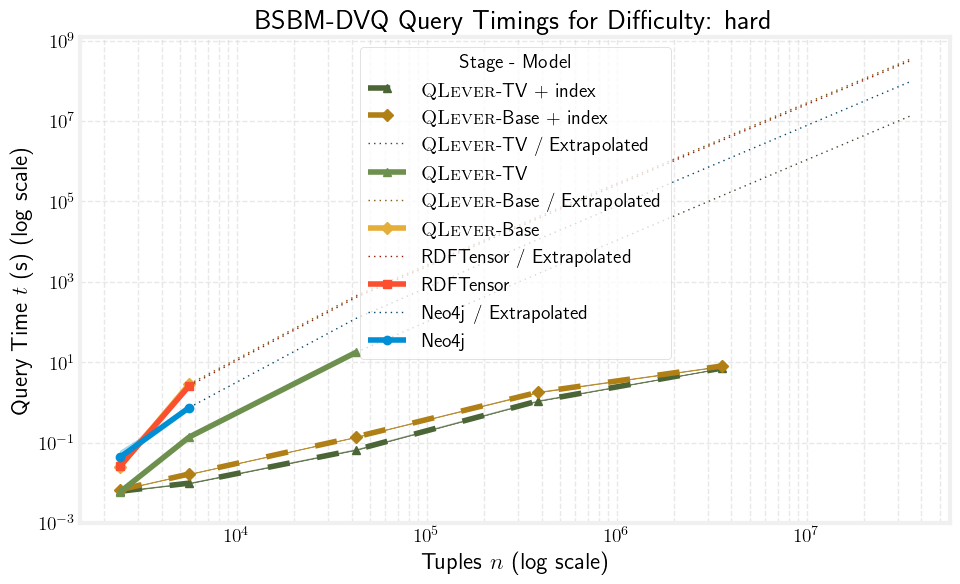

In [254]:
from numpy.polynomial import Polynomial, Hermite, Chebyshev


def extrapolate_missing_sizes(
    df,
    possible_sizes,
    relevant_measure,
    fns=[
        lambda x: x**2,
        lambda x: x,
        lambda x: np.sqrt(x),
        lambda x: np.ones_like(x),
    ],
):
    df_filtered = df[df[relevant_measure].replace([np.inf, -np.inf], np.nan).notna()]

    missing_sizes = [s for s in possible_sizes if s not in df_filtered["size"].unique()]
    missing_sizes.sort()
    # missing_sizes = missing_sizes[:-1]
    missing_sizes = np.array(missing_sizes)
    if df_filtered.empty or len(missing_sizes) == 0:
        return None
    x_data = df_filtered["size"].values
    y_data = df_filtered[relevant_measure].values

    poly = Polynomial.fit(x_data, y_data, deg=2)
    y_pred = poly(missing_sizes)
    # if (y_pred <= 0).any():
    # Phi = np.column_stack([fn(x_data) for fn in fns])
    # # calculate the coefficients using least squares with regularization to prevent overfitting
    # lbd = 0.0
    # coefs = (
    #     np.linalg.inv(Phi.T @ Phi / x_data.shape[0] + lbd * np.eye(Phi.shape[1]))
    #     @ Phi.T
    #     @ y_data
    # )
    # print("Coefficients for extrapolation:", coefs)
    # y_pred = np.dot(coefs, [fn(missing_sizes) for fn in fns])
    extrapolated_df = pd.DataFrame(
        {
            "size": missing_sizes,
            relevant_measure: y_pred,
        }
    )
    if extrapolated_df.empty:
        return None
    # add last known size and measure to the extrapolated df to make the plot look better
    last_known_size = df_filtered["size"].max()
    last_known_measure = df_filtered[df_filtered["size"] == last_known_size][
        relevant_measure
    ].values[0]
    extrapolated_df = pd.concat(
        [
            pd.DataFrame(
                {"size": [last_known_size], relevant_measure: [last_known_measure]}
            ),
            extrapolated_df,
        ],
        ignore_index=True,
    )
    return extrapolated_df


def fit_to_fn(df, relevant_measure, fn: (lambda x: x)):
    df_filtered = df[df[relevant_measure].replace([np.inf, -np.inf], np.nan).notna()]
    if df_filtered.empty:
        return None
    x_data = df_filtered["size"].values
    # y_data = df_filtered[relevant_measure].values
    const = x_data[0] if x_data[0] > 0 else 1
    x_data_fn = fn(x_data / const) * const
    Phi = np.vstack([x_data_fn, np.ones(len(x_data_fn))])
    coeffs = np.linalg.lstsq(Phi, df_filtered[relevant_measure].values, rcond=None)[0]
    a, b = coeffs
    y_fitted = a * x_data_fn + b
    fitted_df = pd.DataFrame(
        {
            "size": x_data,
            relevant_measure: y_fitted,
        }
    )
    return fitted_df


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(
    ax,
    df,
    engine,
    difficulty,
    relevant_measure="elapsed_time",
    extrapolate=True,
    fill_pdf=True,
    pdf_steps=5,
    fit_fn=None,
):
    groupings: pd.Series = df.groupby(["size", "engine", "difficulty", "query_type"])[
        relevant_measure
    ]
    quantiles = (
        [0.05, 0.5, 0.95]
        if not fill_pdf
        else np.linspace(0, 1, 1 + pdf_steps * 2).tolist()
    )
    print("Quantiles", quantiles)
    mean_timings = groupings.mean().reset_index()
    std_timings = groupings.std().reset_index()
    median_timings = groupings.median().reset_index()
    quantile_timings = groupings.quantile(quantiles).unstack().reset_index()
    possible_sizes = sorted(df["size"].unique())
    all_extended_dfs = []
    for query_type in [QUERY_TYPE.INDEX, QUERY_TYPE.EMBEDDED]:
        for engine in engines[::-1]:
            engine_mean = mean_timings[
                (mean_timings["query_type"] == type_map[query_type.value])
                & (mean_timings["difficulty"] == difficulty)
                & (mean_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == type_map[query_type.value])
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            engine_median = median_timings[
                (median_timings["query_type"] == type_map[query_type.value])
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_std = std_timings[
                (std_timings["query_type"] == type_map[query_type.value])
                & (std_timings["difficulty"] == difficulty)
                & (std_timings["engine"] == engine)
            ]
            if engine_mean.empty or engine_quantiles.empty:
                continue

            extrapolated_df = None
            engine_median = engine_median[engine_median[relevant_measure].notna()]
            engine_quantiles = engine_quantiles[engine_median[relevant_measure].notna()]
            engine_std = engine_std[engine_median[relevant_measure].notna()]
            engine_mean = engine_mean[engine_median[relevant_measure].notna()]
            # extrapolate missing sizes by linear regression

            if extrapolate:
                extrapolated_df = extrapolate_missing_sizes(
                    engine_median, possible_sizes, relevant_measure
                )

            # index are dashed, embedded are solid
            linestyle = (0, (4, 5)) if query_type == QUERY_TYPE.INDEX else "-"
            color = colors[engine]
            if query_type == QUERY_TYPE.INDEX:
                color = adjust_lightness(color, 0.7)
            symbol = symbols[engine]
            lbl = f"{engine}"
            if query_type.value != QUERY_TYPE.EMBEDDED.value:
                lbl += f" + {query_type.value}"
            # lbl += " $t$"
            if (
                extrapolated_df is not None
                and not extrapolated_df.empty
                and extrapolated_df.shape
                and (extrapolated_df[relevant_measure] > 0).all()
            ):
                all_extended_dfs.append(extrapolated_df)
                print(
                    f"Extrapolated sizes for {engine} - {query_type.value}: {extrapolated_df['size'].tolist()}",
                    extrapolated_df[relevant_measure].tolist(),
                    "existing points",
                    engine_median["size"].tolist(),
                    engine_median[relevant_measure].tolist(),
                )
                ax.plot(
                    extrapolated_df["size"],
                    extrapolated_df[relevant_measure],
                    linestyle=(0, (1, 3)),
                    label=f"{lbl} / Extrapolated",
                    color=adjust_lightness(color, 0.5),
                    linewidth=1,
                )
            if fit_fn is not None and fit_fn is not False:
                fit_fn = (
                    fit_fn if isinstance(fit_fn, type(lambda: None)) else lambda x: x
                )
                fitted_df = fit_to_fn(
                    engine_median,
                    relevant_measure,
                    fn=fit_fn,
                )
                if fitted_df is not None and not fitted_df.empty:
                    ax.plot(
                        fitted_df["size"],
                        fitted_df[relevant_measure],
                        linestyle=(0, (5, 10)),
                        label=f"{lbl} / Fit",
                        color=adjust_lightness(color, 0.8),
                        linewidth=1,
                    )
            ax.plot(
                engine_median["size"],
                engine_median[relevant_measure],
                symbol,
                linestyle=linestyle,
                label=lbl,
                color=color,
                linewidth=4,
            )
            if fill_pdf:
                if engine_median["size"].shape[0] > 1:
                    for i in range(0, pdf_steps - 1):
                        ax.fill_between(
                            engine_quantiles["size"],
                            engine_quantiles[quantiles[pdf_steps - 1 - i]],
                            engine_quantiles[quantiles[pdf_steps + 1 + i]],
                            color=color,
                            alpha=0.3,
                        )
            else:
                upper_std = engine_quantiles[0.95] - engine_median[relevant_measure]
                lower_std = engine_median[relevant_measure] - engine_quantiles[0.05]
                # lower_std[engine_median[relevant_measure] - lower_std <= 0] = np.abs(
                #     engine_median[relevant_measure] - 1e-12
                # )
                # if "time" in relevant_measure:
                #     lower_std[lower_std <= 0] = 1e-2
                ax.errorbar(
                    engine_median["size"],
                    engine_median[relevant_measure],
                    yerr=[
                        lower_std,
                        upper_std,
                    ],
                    barsabove=True,
                    capsize=5,
                    linewidth=1,
                    fmt="none",
                    # label=f"5\%-95\% quantiles ({engine})",
                    color=color,
                )
    return pd.concat(all_extended_dfs) if all_extended_dfs else None


overview_dir = figures_dir / "overview"
overview_dir.mkdir(exist_ok=True, parents=True)


def calc_extra_ticks(series: pd.Series, tweens=[2, 3, 4, 5, 6, 7, 8, 9]):
    series = series.replace([np.inf, -np.inf], np.nan).dropna()
    min_size = int(np.log10(series.min())) - 1
    max_size = int(np.log10(series.max())) + 2

    extra_ticks = [10**i * tween for i in range(min_size, max_size) for tween in tweens]
    return extra_ticks


extra_y_ticks = calc_extra_ticks(timings_df["elapsed_time"])
extra_x_ticks = calc_extra_ticks(timings_df["size"])
for fill_pdf in [False, True]:
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # ax = axes[i] if len(difficulties) > 1 else axes
        # set the suxbtitle to the difficulty

        extended_dfs = plot_timings(
            ax,
            timings_df,
            engines,
            difficulty,
            fill_pdf=fill_pdf,
            fit_fn=False,
            extrapolate=True,
        )
        complete_plotted_df = (
            pd.concat([timings_df, extended_dfs])
            if extended_dfs is not None
            else timings_df
        )
        extra_y_ticks_plt = calc_extra_ticks(complete_plotted_df["elapsed_time"])
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Tuples $n$ (log scale)")
        ax.set_ylabel("Query Time $t$ (s) (log scale)")
        ax.set_title(f"{modes.get(mode, mode)} Query Timings for Difficulty: {difficulty}")
        ax.set_ylim(bottom=1e-3)
        ax.legend()
        ax.grid(True, which="both", ls="--", color="lightgray", alpha=0.5)
        fill_str = "_filled" if fill_pdf else ""
        tikzplotlib.save(
            overview_dir / f"{mode}_timings_{difficulty}{fill_str}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                        legend pos=south west, 
                        legend style={
                    font=\\small},
                        legend columns=2, 
                        extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                        extra y ticks={"""
                + ",".join(map(str, extra_y_ticks_plt))
                + """},
                        extra x tick labels={ },
                        extra y tick labels={ },
                        extra tick style={
                            tick style={draw=none},
                            major grid style={dashed,red},
                            grid=major,
                        },
                    }""",
            ],
            axis_height="1.2\\linewidth",
            axis_width="2\\linewidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            overview_dir / f"{mode}_timings_{difficulty}_legend{fill_str}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                        legend pos=south west, 
                        legend style={
                    font=\\small},
                        legend columns=5, 
                        extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                        extra y ticks={"""
                + ",".join(map(str, extra_y_ticks_plt))
                + """},
                        extra x tick labels={ },
                        extra y tick labels={ },
                        extra tick style={
                            tick style={draw=none},
                            major grid style={dashed,red},
                            grid=major,
                        },
                    }""",
            ],
            axis_height="1.2\\linewidth",
            axis_width="2\\linewidth",
        )
        # plt.savefig(overview_dir / f"{mode}_timings_{difficulty}{fill_str}.png")
        # plt.show()

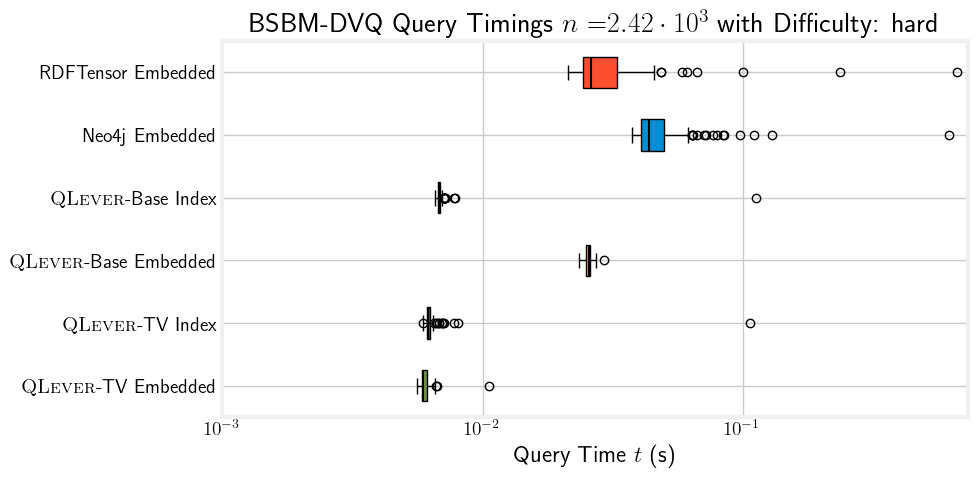

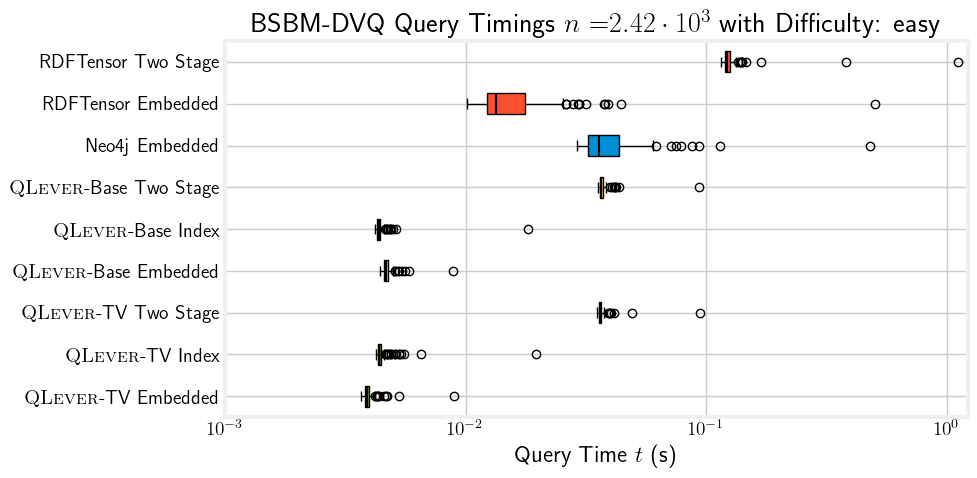

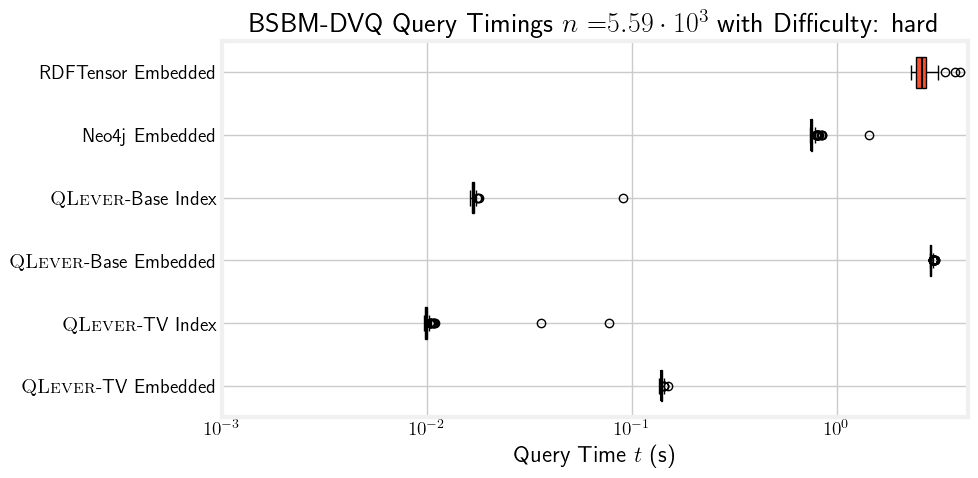

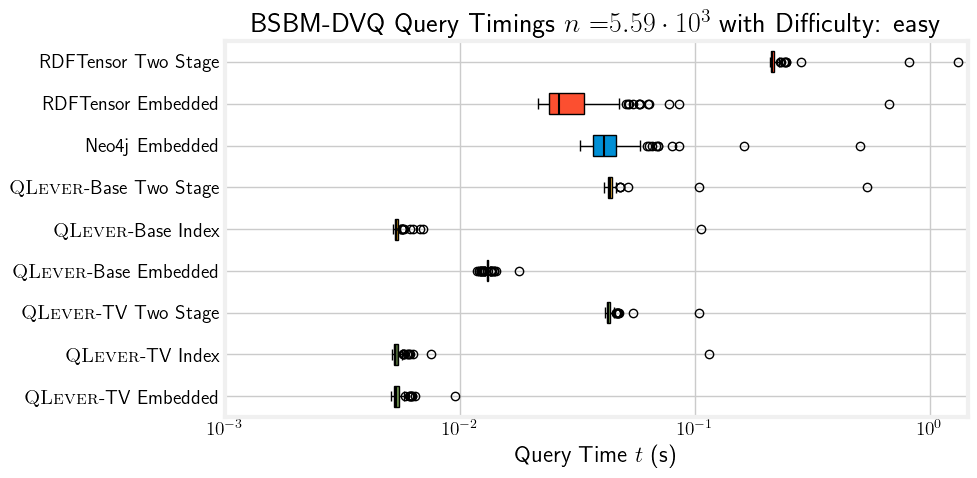

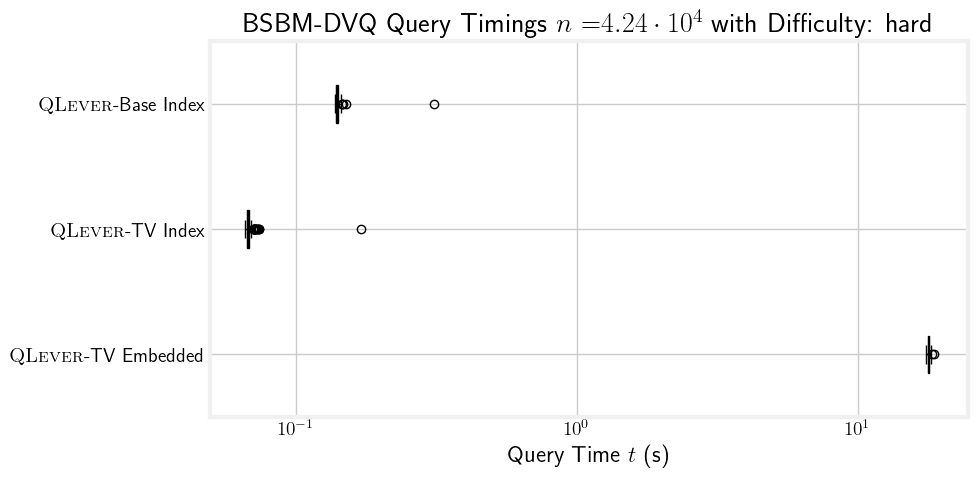

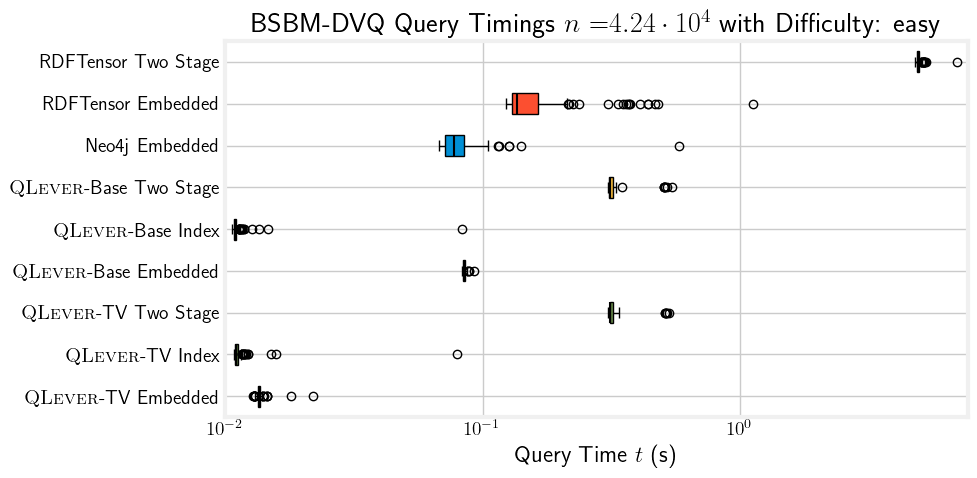

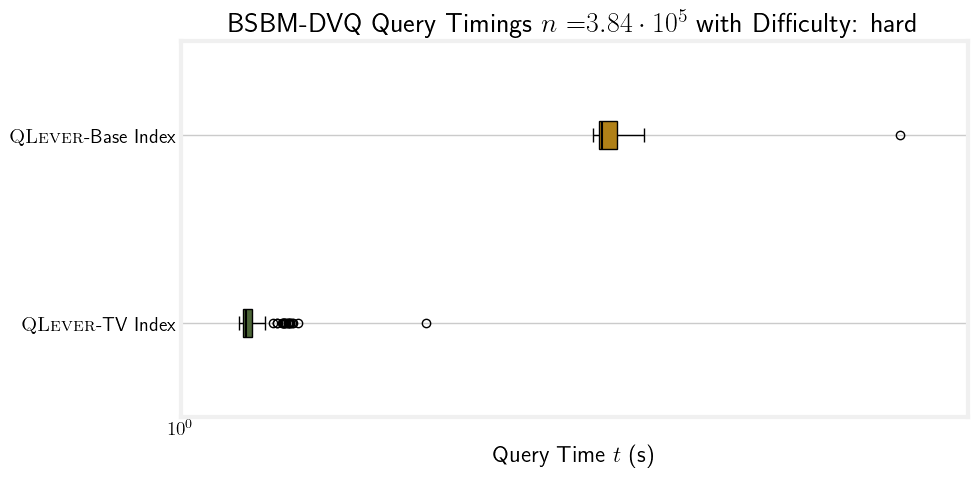

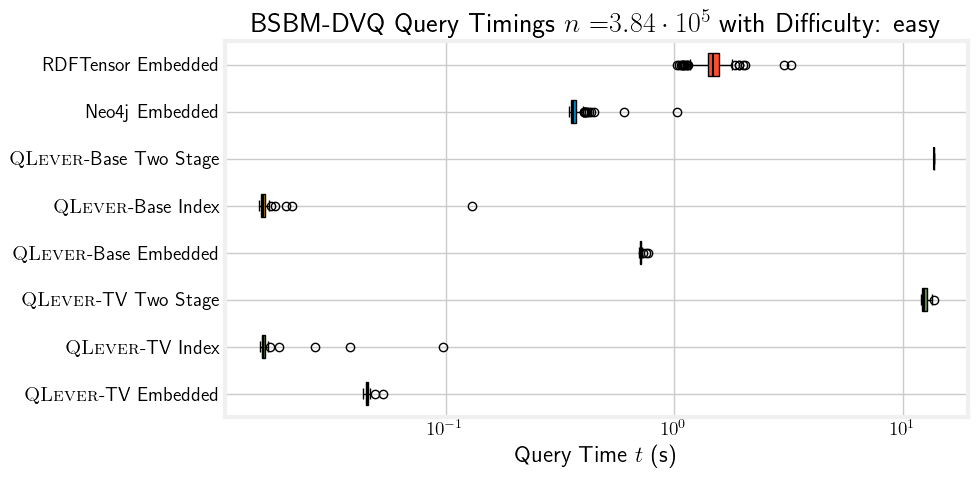

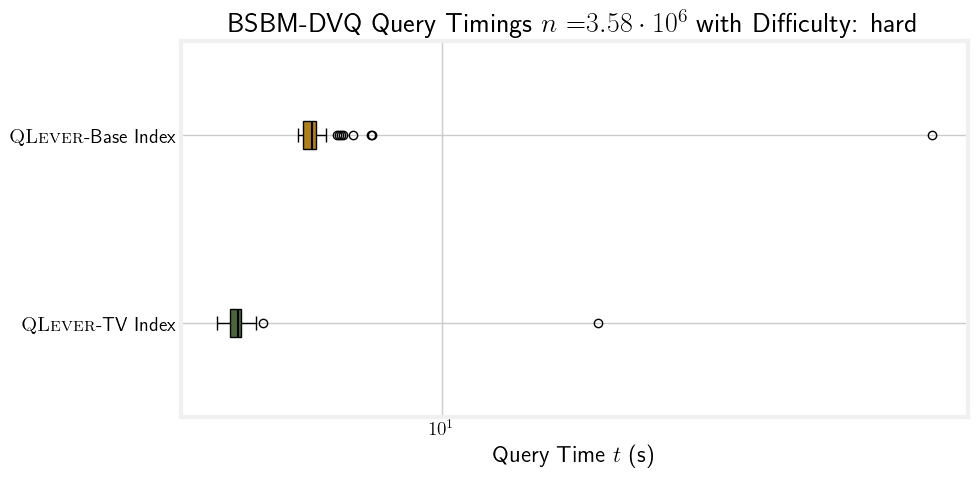

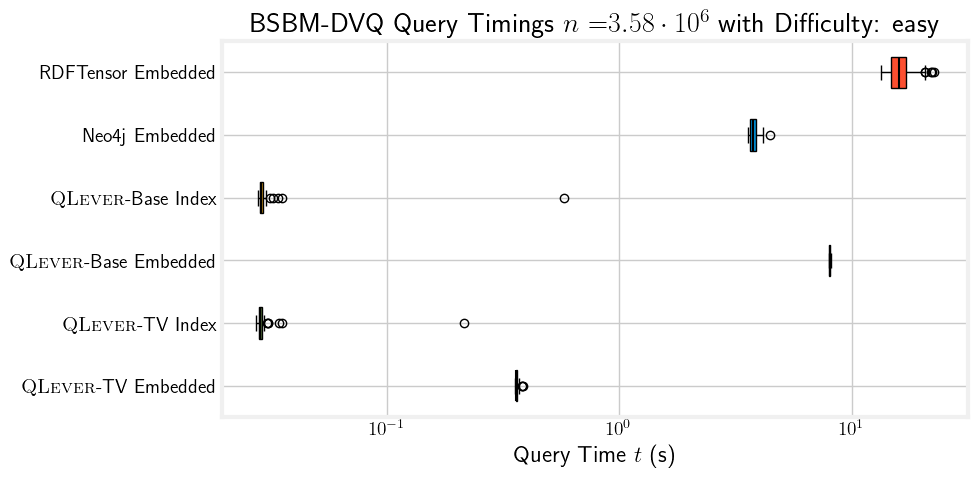

No measures for size 35177974 and difficulty hard


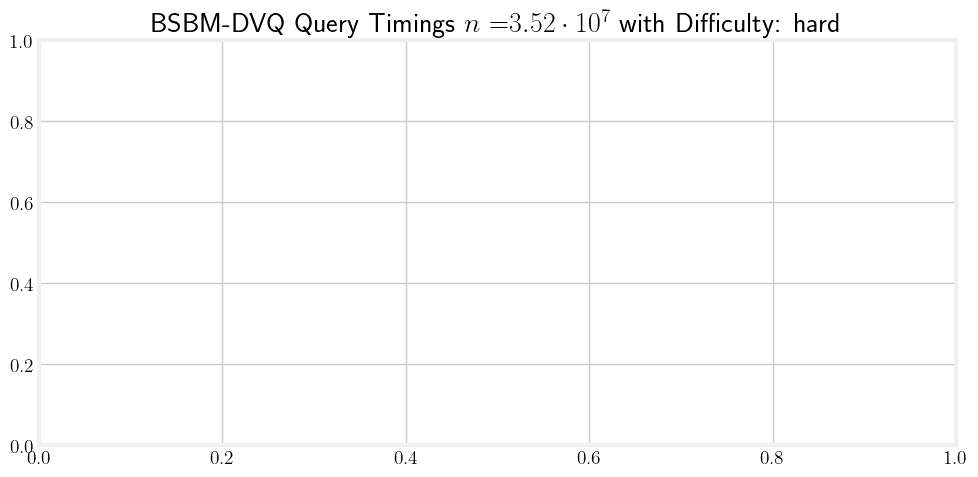

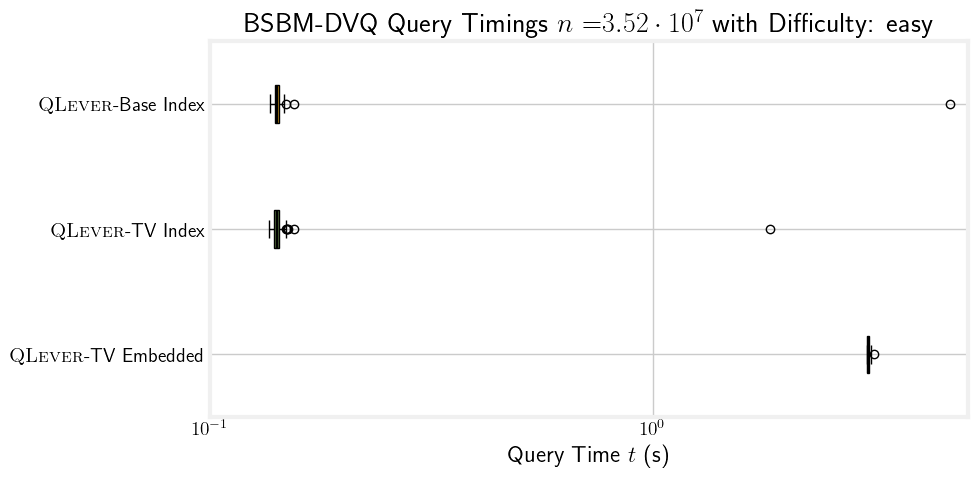

In [255]:
def plot_boxplot(
    ax: plt.Axes,
    df: pd.DataFrame,
    size: int,
    difficulty: str,
    relevant_measure: str = "elapsed_time",
):
    ax.set_title(
        f" {modes[mode]} Query Timings $n=${to_pow_10(size)} with Difficulty: {difficulty}"
    )
    size_df = df[df["size"] == size]
    engine_types = size_df.apply(
        lambda row: (row["engine"], row["query_type"]), axis=1
    ).unique()

    tick_labels = list(engine_types)
    measures: list[pd.Series] = [
        size_df[
            (size_df["difficulty"] == difficulty)
            & (size_df["engine"] == engine)
            & (size_df["query_type"] == query_type)
        ][relevant_measure]
        for engine, query_type in tick_labels
    ]
    # filter infinite and nan values from measures and corresponding tick labels
    measures_f = [
        measures[i].replace([np.inf, -np.inf], np.nan).dropna()
        for i in range(len(measures))
    ]
    measures = [
        measures_f[i] for i in range(len(measures_f)) if not measures_f[i].shape[0] == 0
    ]
    tick_labels = [
        tick_labels[i]
        for i in range(len(tick_labels))
        if not measures_f[i].shape[0] == 0
    ]
    if len(measures) == 0:
        print(f"No measures for size {size} and difficulty {difficulty}")
        return
    all_measures = pd.concat(measures)
    bplot = ax.boxplot(
        measures,
        tick_labels=[f"{engine} {query_type}" for engine, query_type in tick_labels],
        vert=False,
        patch_artist=True,
        medianprops={"color": "black", "linewidth": 1.5},
        # showfliers=False,
    )
    ax.set_xlabel("Query Time $t$ (s)")
    ax.set_xscale("log")
    ax.set_xticklabels([], minor=True)
    # fill with colors
    for patch, (engine, query_type) in zip(bplot["boxes"], tick_labels):
        color = colors[engine]
        if query_type == "Index":
            color = adjust_lightness(color, 0.7)
        patch.set_facecolor(
            adjust_lightness(color)
            if query_type == QUERY_TYPE.INDEX.value
            else color
        )
    if abs(all_measures.min() - all_measures.max()) < 10:
        min_power = int(np.floor(np.log10(all_measures.min())))
        max_power = int(np.ceil(np.log10(all_measures.max())))
        ax.set_xlim(left=10**min_power, right=all_measures.max()*1.1)


boxplots_dir = figures_dir / "boxplots"
boxplots_dir.mkdir(exist_ok=True, parents=True)
for est_size in timings_df["estimated_size"].unique():
    for difficulty in difficulties[::-1]:
        fig, ax = plt.subplots(1, figsize=(10, 5))
        eval_size = timings_df[timings_df["estimated_size"] == est_size][
            "size"
        ].unique()[0]
        plot_boxplot(ax, timings_df, eval_size, difficulty)
        plt.tight_layout()
        tikzplotlib.save(
            boxplots_dir / f"{mode}_boxplot_{est_size}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=2, 
                    extra x ticks={"""
                + ",".join(map(str, extra_y_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="0.7\\linewidth",
            axis_width="1.25\\linewidth",
        )
        plt.savefig(boxplots_dir / f"{mode}_boxplot_{est_size}_{difficulty}.png")
        plt.show()

In [256]:
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-05-12 21:19:24.648975,0.0,72261632,-1,-1,1,2418,3,easy,Embedded,1,\systemname-TV
1,2026-05-12 21:19:24.797419,33.7,79941632,-1,-1,1,2418,3,easy,Embedded,1,\systemname-TV
2,2026-05-12 21:19:24.948502,33.1,79937536,-1,-1,1,2418,3,easy,Embedded,1,\systemname-TV
3,2026-05-12 21:19:25.098408,33.3,79958016,-1,-1,1,2418,3,easy,Embedded,1,\systemname-TV
4,2026-05-12 21:19:25.246388,33.8,79958016,-1,-1,1,2418,3,easy,Embedded,1,\systemname-TV
...,...,...,...,...,...,...,...,...,...,...,...,...
112466,2026-05-13 02:04:09.921108,0.0,726343680,-1,-1,1,35177974,7,hard,Two Stage,100000,RDFTensor
112467,2026-05-13 02:04:17.525394,0.3,726343680,-1,-1,1,35177974,7,hard,Two Stage,100000,RDFTensor
112468,2026-05-13 02:04:25.785013,0.0,726343680,-1,-1,1,35177974,7,hard,Two Stage,100000,RDFTensor
112469,2026-05-13 02:04:36.093810,0.2,726343680,-1,-1,1,35177974,7,hard,Two Stage,100000,RDFTensor


In [257]:
stats_df["cpu_percent"] = stats_df["cpu_percent"].astype(float)
stats_df["mem_usage_mb"] = stats_df["mem_usage"].astype(float) / (1024 * 1024)  # in MiB

Quantiles [0.05, 0.5, 0.95]


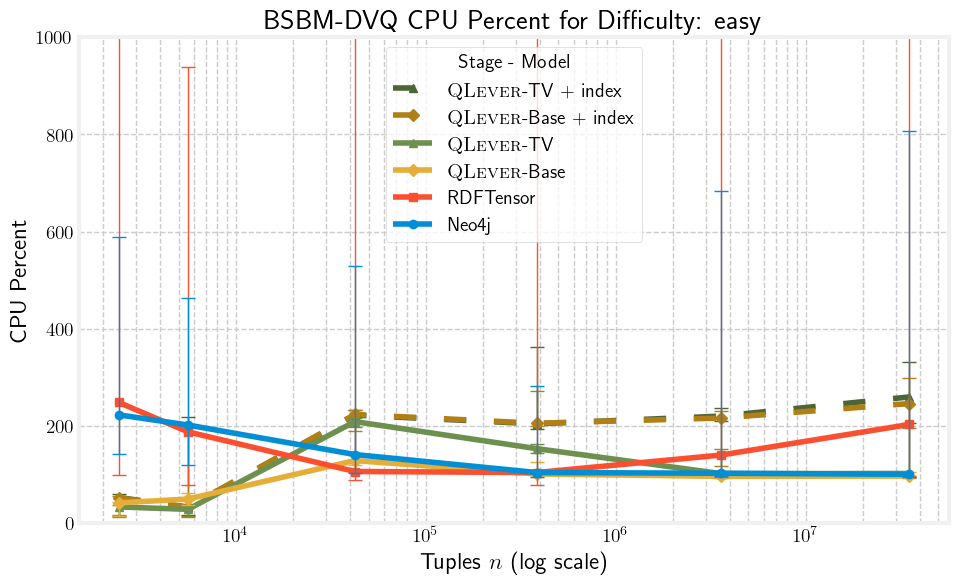

Quantiles [0.05, 0.5, 0.95]


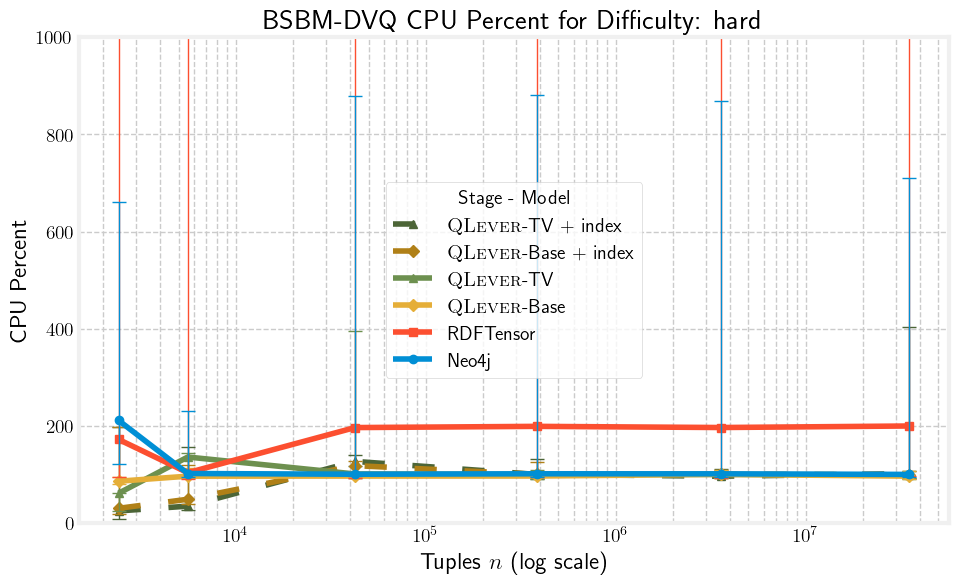

Quantiles [0.05, 0.5, 0.95]


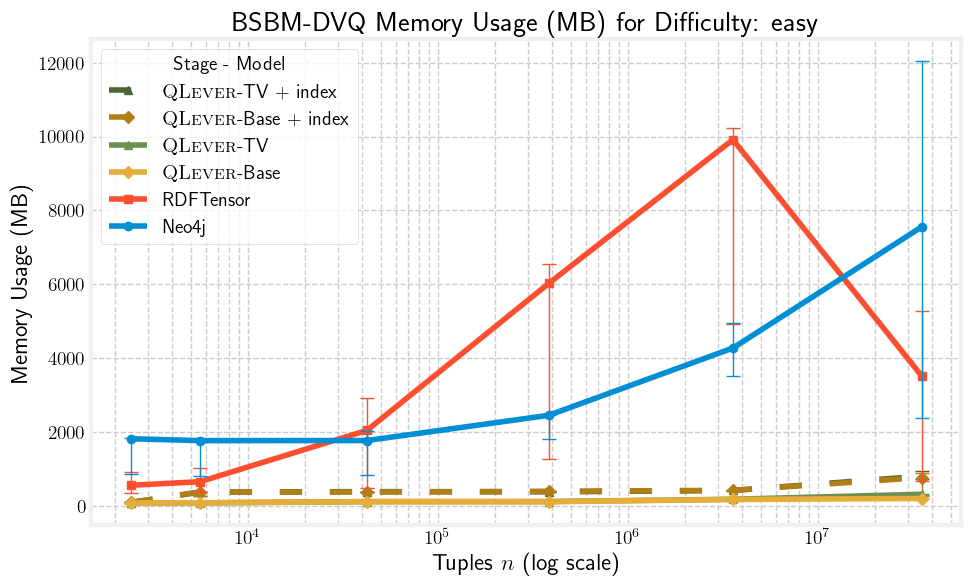

Quantiles [0.05, 0.5, 0.95]


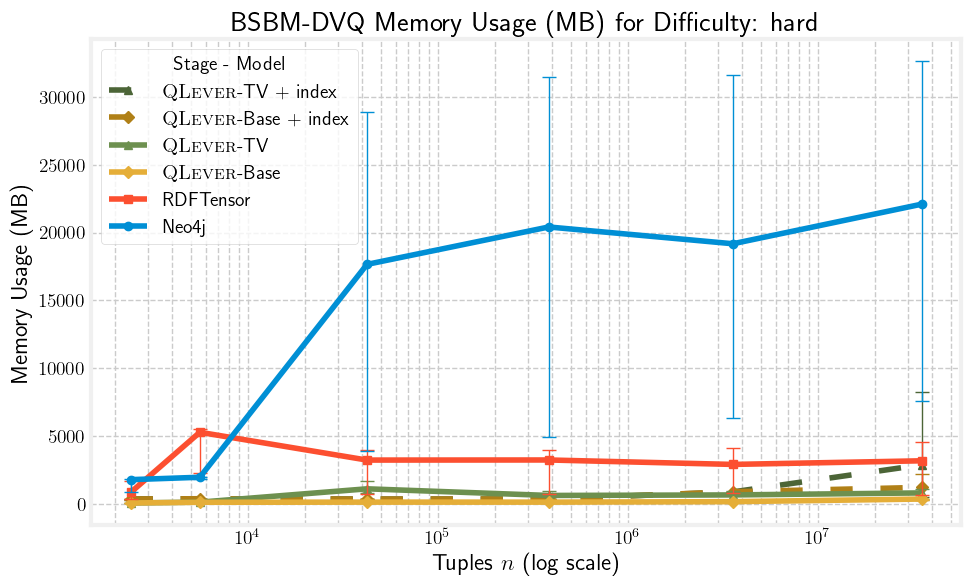

In [258]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.

relevant_stats_map = {
    "cpu_percent": "CPU Percent",
    "mem_usage_mb": "Memory Usage (MB)",
}
stat_dir = figures_dir / "stats"
stat_dir.mkdir(exist_ok=True, parents=True)
for relevant_measure, ylabel in relevant_stats_map.items():
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # set the subtitle to the difficulty

        plot_timings(
            ax,
            stats_df,
            engines,
            difficulty,
            relevant_measure=relevant_measure,
            extrapolate=False,
            fill_pdf=False,
        )
        ax.set_xscale("log")
        ax.set_xlabel("Tuples $n$ (log scale)")
        ax.set_ylabel(ylabel)
        ax.set_title(f" {modes[mode]} {ylabel} for Difficulty: {difficulty}")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        if relevant_measure == "cpu_percent":
            ax.set_ylim(0, 1000)
            ax.legend()
        # y_grids = calc_extra_ticks(stats_df[relevant_measure])
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1.2\\linewidth",
            axis_width="2\\linewidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}_legend.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1.2\\linewidth",
            axis_width="2\\linewidth",
        )
        plt.savefig(stat_dir / f"{mode}_{relevant_measure}_{difficulty}.png")
        plt.show()


Quantiles [0.05, 0.5, 0.95]


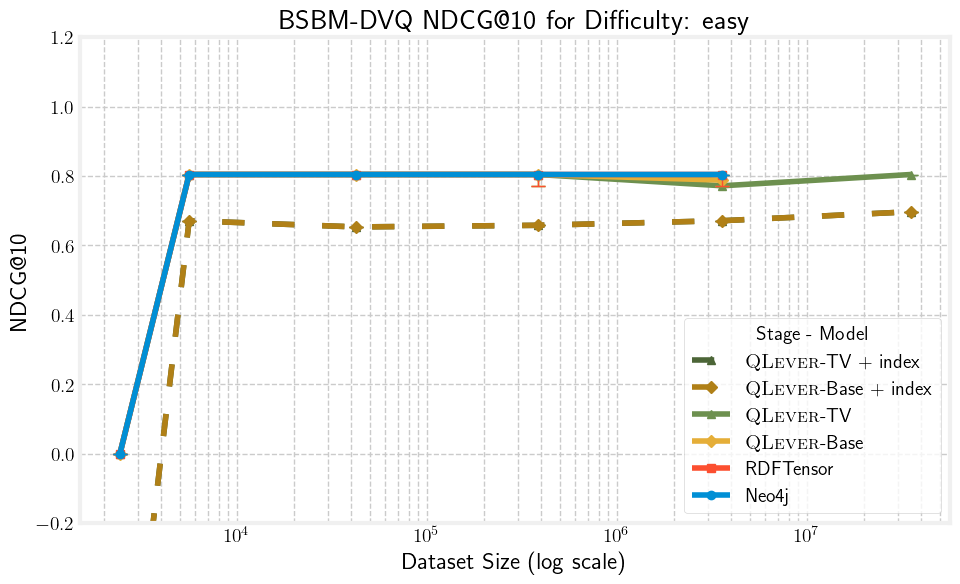

Quantiles [0.05, 0.5, 0.95]


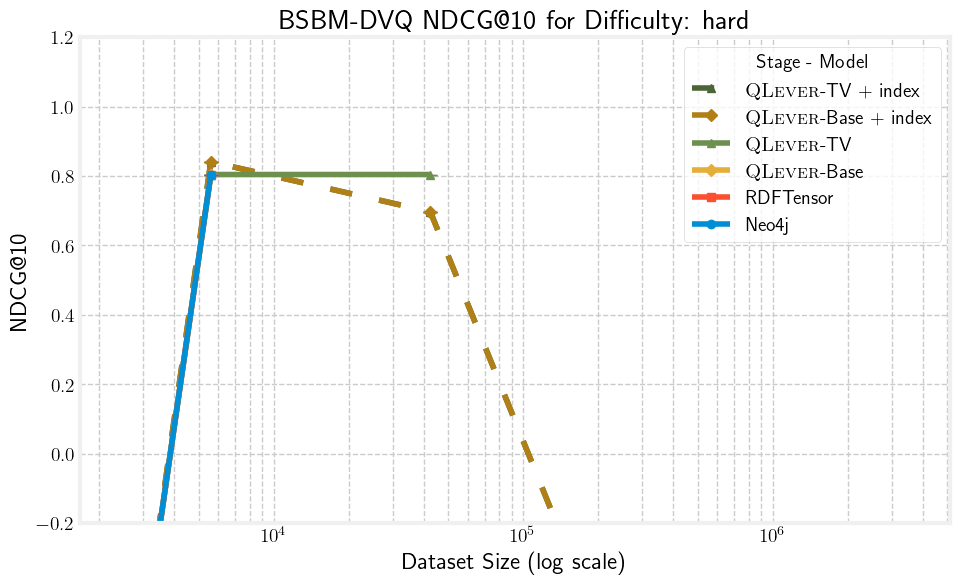

Quantiles [0.05, 0.5, 0.95]


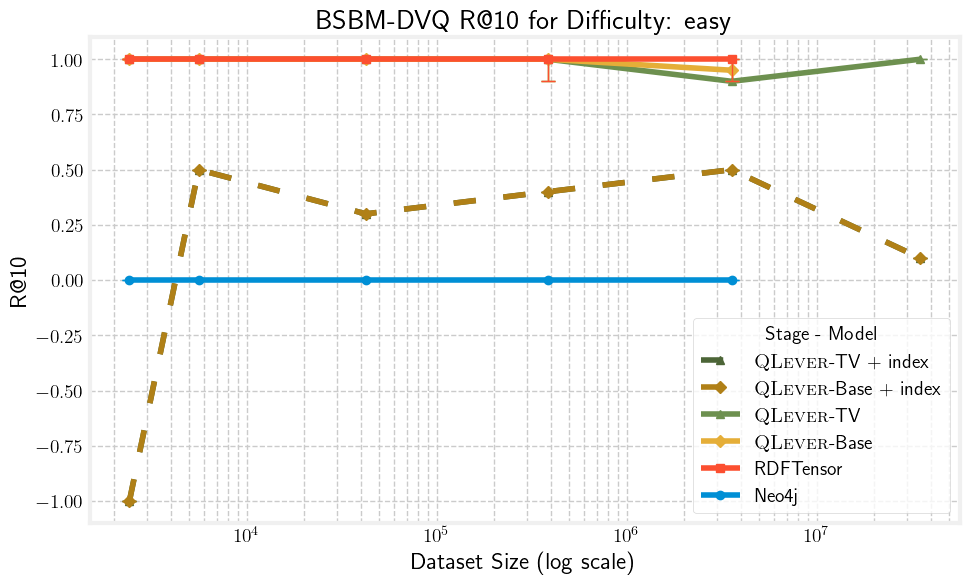

Quantiles [0.05, 0.5, 0.95]


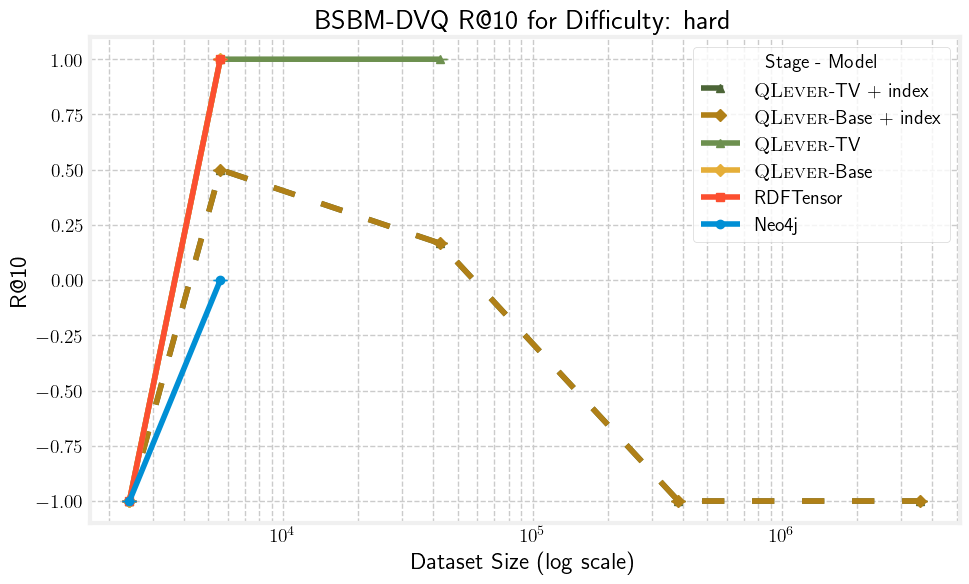

Quantiles [0.05, 0.5, 0.95]


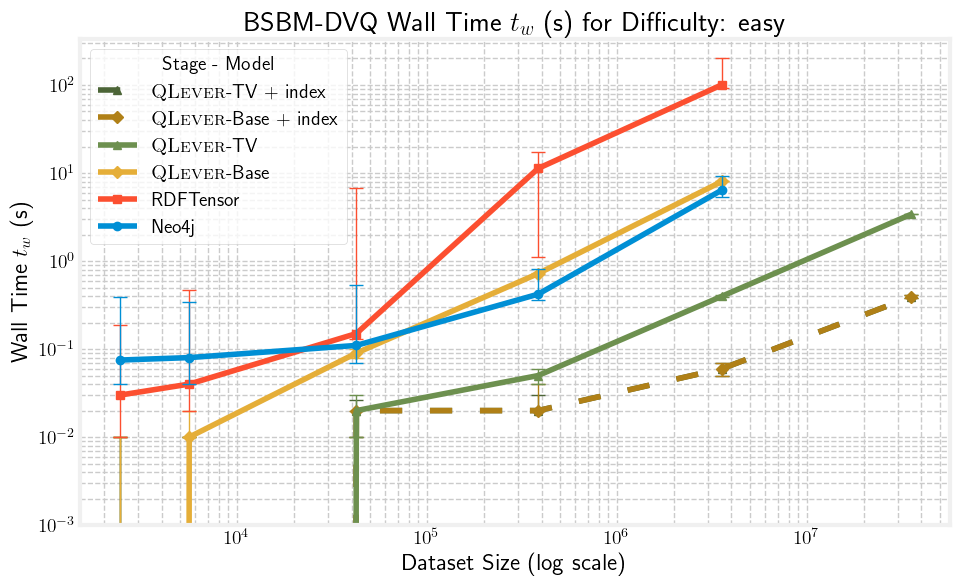

Quantiles [0.05, 0.5, 0.95]


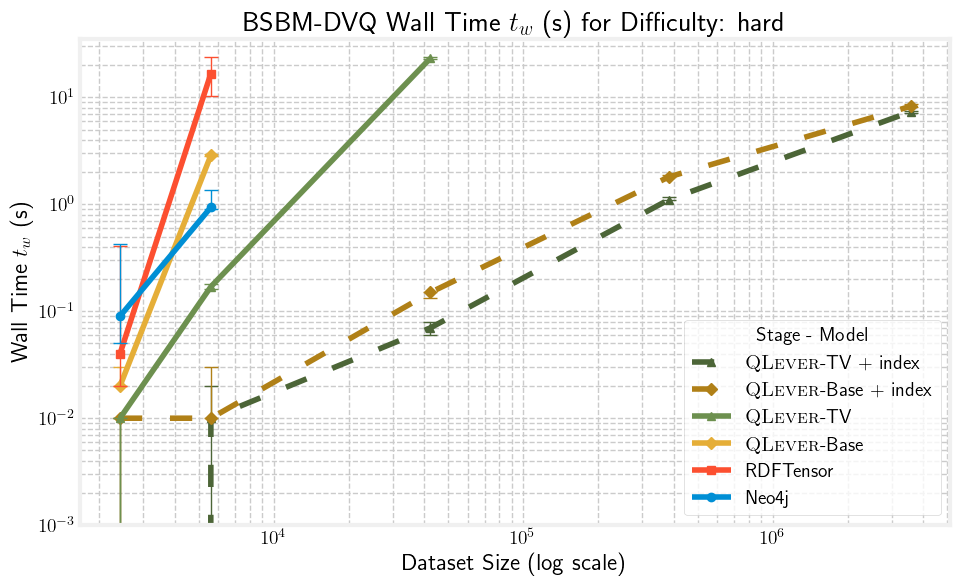

In [259]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.

relevant_measure_map = {
    "ndcg_score": "NDCG@10",
    "recall_score": "R@10",
    "wall_time": "Wall Time $t_w$ (s)",
}
stat_dir = figures_dir / "stats"
stat_dir.mkdir(exist_ok=True, parents=True)
for relevant_measure, ylabel in relevant_measure_map.items():
    for i, difficulty in enumerate(difficulties):
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        # set the subtitle to the difficulty

        plot_timings(
            ax,
            timings_df,
            engines,
            difficulty,
            relevant_measure=relevant_measure,
            extrapolate=False,
            fill_pdf=False,
        )
        ax.set_xscale("log")
        ax.set_xlabel("Dataset Size (log scale)")
        ax.set_ylabel(ylabel)
        ax.set_title(f" {modes[mode]} {ylabel} for Difficulty: {difficulty}")
        ax.legend()
        ax.grid(True, which="both", ls="--")
        if relevant_measure == "wall_time":
            ax.set_yscale("log")
            ax.set_ylim(bottom=1e-3)
        elif relevant_measure == "ndcg_score":
            ax.set_ylim(-0.2, 1.2)
        ax.legend()
        # y_grids = calc_extra_ticks(stats_df[relevant_measure])
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1.2\\linewidth",
            axis_width="2\\linewidth",
        )
        legend = ax.legend(title="Stage - Model")
        legend.set_ncols(2)
        tikzplotlib.save(
            stat_dir / f"{mode}_{relevant_measure}_{difficulty}_legend.tex",
            extra_tikzpicture_parameters=[
                "scale=0.5",
                """every axis/.style={
                    legend pos=south west, 
                    legend style={
                font=\\small},
                    legend columns=5, 
                    extra x ticks={"""
                + ",".join(map(str, extra_x_ticks))
                + """},
                    extra x tick labels={ },
                    extra y tick labels={ },
                    extra tick style={
                        tick style={draw=none},
                        major grid style={dashed,red},
                        grid=major,
                    },
                }""",
            ],
            axis_height="1.2\\linewidth",
            axis_width="2\\linewidth",
        )
        plt.savefig(stat_dir / f"{mode}_{relevant_measure}_{difficulty}.png")
        plt.show()


In [260]:
index_test_dir = results_dir / mode / "index_tests"
index_test_timing_file = index_test_dir / "index_query_timings.csv"
if index_test_timing_file.exists():
    index_test_timings_df = pd.read_csv(index_test_timing_file)
else:
    index_test_timings_df = pd.DataFrame()
index_test_timings_df

,mode,run,time,searchK,ndcg_score,recall_score
0,hnsw,0,0.032583,1,0.720303,0.0625
1,hnsw,1,0.029950,1,0.668435,0.1875
2,hnsw,2,0.029731,1,0.807537,0.0000
3,hnsw,3,0.029625,1,0.668435,0.1875
4,hnsw,4,0.030338,1,0.668435,0.1875
...,...,...,...,...,...,...
4603,ivf,251,0.032561,16,0.807537,1.0000
4604,ivf,252,0.033363,16,0.807537,1.0000
4605,ivf,253,0.033745,16,0.807537,1.0000
4606,ivf,254,0.032958,16,0.807537,1.0000


  searchK recall_score              time          
                  0.25    0.75      0.25      0.75
0       1       0.0000  0.1875  0.029955  0.031495
1       4       0.1250  0.3750  0.030000  0.030934
2       8       0.2500  0.5000  0.030292  0.031357
3      12       0.3750  0.6250  0.030838  0.032493
4      16       0.4375  0.6250  0.030582  0.031840
5      20       0.5000  0.6875  0.030645  0.031742
6      24       0.5625  0.7500  0.031243  0.032536
7      28       0.5625  0.8125  0.030803  0.032691
8      32       0.6250  0.8125  0.031541  0.033064
  searchK recall_score              time          
                  0.25    0.75      0.25      0.75
0       1     0.125000  0.3125  0.030755  0.031924
1       2     0.250000  0.4375  0.031179  0.032721
2       4     0.437500  0.6250  0.031258  0.032563
3       6     0.562500  0.8125  0.031529  0.032916
4       8     0.734375  0.8750  0.031658  0.032939
5      10     0.812500  0.9375  0.031825  0.033117
6      12     0.875000  1.0000 

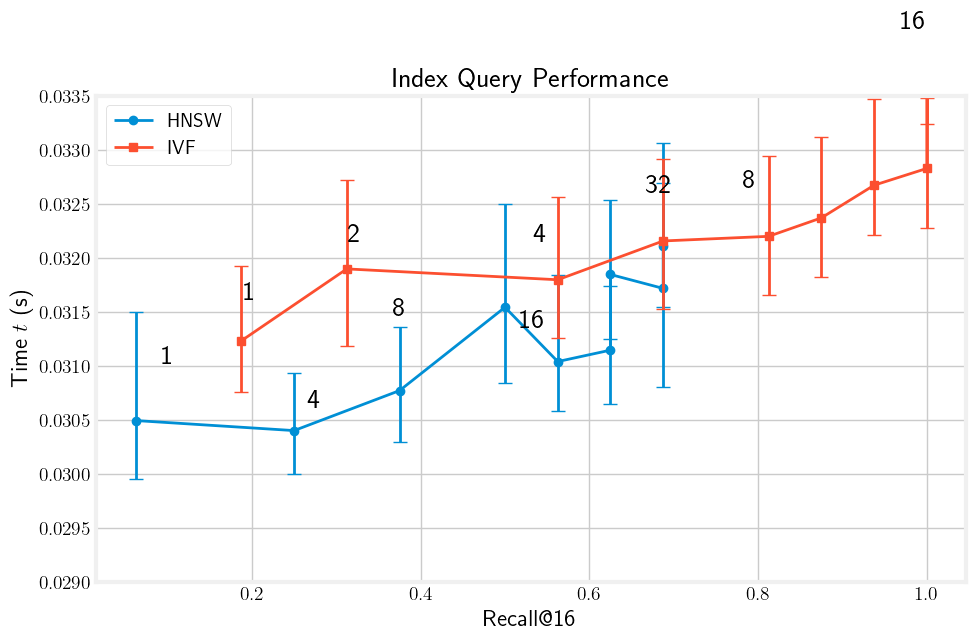

In [261]:
from re import search


mode_names = {"hnsw": "HNSW", "ivf": "IVF"}
mode_colors = {
    mode: color
    for mode, color in zip(mode_names.keys(), ["C0", "C1", "C2", "C3", "C4"])
}


def plot_dual_plot(
    ax: plt.Axes,
    df: pd.DataFrame,
    mode: str,
    relevant_measure_y: str = "time",
    relevant_measure_x: str = "recall_score",
    varying_param: str = "searchK",
    quantiles=[0.25, 0.75],
):
    if df.empty:
        print(f"No data for engine {mode} and difficulty {difficulty}")
        return
    df_filtered = df[
        (df["mode"] == mode)
        & (df[relevant_measure_x].replace([np.inf, -np.inf], np.nan).notna())
        & (df[relevant_measure_y].replace([np.inf, -np.inf], np.nan).notna())
    ]
    if df_filtered.empty:
        print(f"No data for engine {mode} and difficulty {difficulty}")
        return
    df_filtered.sort_values(varying_param, inplace=True)
    search_group = df_filtered.groupby([varying_param])[
        [relevant_measure_x, relevant_measure_y]
    ]
    search_group_mean = search_group.mean().reset_index()
    search_group_median = search_group.median().reset_index()
    search_group_quantiles = search_group.quantile(quantiles).unstack().reset_index()
    search_group_std = search_group.std().reset_index()
    qps = 1 / search_group_mean[relevant_measure_y]
    ax.plot(
        search_group_median[relevant_measure_x],
        search_group_median[relevant_measure_y],
        marker="o" if mode == "hnsw" else "s",
        label=mode_names.get(mode, mode),
        color=mode_colors[mode],
        linewidth=2,
        # linestyle="--",
    )
    print(search_group_quantiles)
    ax.errorbar(
        search_group_median[relevant_measure_x],
        search_group_median[relevant_measure_y],
        yerr=[
            search_group_median[relevant_measure_y]
            - search_group_quantiles[relevant_measure_y, quantiles[0]],
            search_group_quantiles[relevant_measure_y, quantiles[1]]
            - search_group_median[relevant_measure_y],
        ],
        fmt="none",
        ecolor=mode_colors[mode],
        alpha=1,
        capsize=5,
        linewidth=2,
    )
    # add labes for searchK values
    draw_rows = (
        2 ** np.arange(0, np.log2(search_group_mean[varying_param].max()) + 1)
    ).tolist()
    for _, row in search_group_mean.iterrows():
        if row[varying_param] in draw_rows:
            ax.text(
                row[relevant_measure_x],
                row[relevant_measure_y],
                f"{int(row[varying_param])}",
                fontsize=20,
                ha="right",
                va="bottom",
            )


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

plot_dual_plot(
    ax,
    index_test_timings_df,
    mode="hnsw",
)
plot_dual_plot(
    ax,
    index_test_timings_df,
    mode="ivf",
)
ax.set_ylabel("Time $t$ (s)")
ax.set_xlabel("Recall@16")
ax.set_title("Index Query Performance")
ax.legend()
ax.set_ylim([0.029, 0.0335])

tikzplotlib.save(
    stat_dir / f"{mode}_index_query_performance.tex",
    extra_tikzpicture_parameters=[
        "scale=0.5",
        """every axis/.style={
            legend pos=south west, 
            legend style={
        font=\\small},
            legend columns=1, 
        }""",
    ],
    axis_height="1.2\\linewidth",
    axis_width="2\\linewidth",
)